# LCA of biofuel productions using OpenLCA from Python and EcoInvent database
by Siyue Zhang

using data from Su, C.-L., & Lee, Y.-M. (2009). Development status and life cycle inventory analysis of biofuels in Taiwan. Energy Policy, 37(2), 754–758. https://doi.org/10.1016/j.enpol.2008.09.076

The code is organized as follows:
- Prepare the data
- Create new flows
- Create new processes
- Create new product systems
- Calculate LCIA results
- Plot the contributions
- Monte Carlo simulation

In [2]:
# openLCA IPC and schema imports
import olca_ipc as ipc # for inter-process communication with openLCA server
import olca_schema as o # for accessing openLCA data structures (ProductSystem, ImpactMethod, etc.)

# Data handling and utilities
import pandas as pd 
import numpy as np
import uuid # for generating unique identifiers
from datetime import datetime

# Plotting
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

import random as rand
import warnings
warnings.filterwarnings('ignore')


### Start communication with OpenLCA client

In [8]:
client = ipc.Client(8080)
client

### Load the dataframe from Excel file

In [100]:
file_path = "./LCIA of biofuels.xlsx"
df_biofuels = pd.read_excel(file_path, engine='openpyxl') 

### Clean the dataframe

In [101]:
df_flow_char = pd.DataFrame({
    'flow_name': df_biofuels['flow name'], 
    'id': df_biofuels['UUID dataset'],
    'flow_property': df_biofuels['flow property'],
    'unit': df_biofuels['unit'], 
    'flow_type': df_biofuels['type'],
    'in/out': df_biofuels['in/out'], 
    'is_ref_flow': df_biofuels['is reference flow?'],
})

df_flow_char 

,flow_name,id,flow_property,unit,flow_type,in/out,is_ref_flow
0,diesel,291fc06d-1b3e-4077-aabb-346b588ed24b,Mass,kg,PRODUCT_FLOW,in,False
1,"nitrogen fertiliser, as N",f5707bdf-f7e2-479b-b3ea-99c04de8a927,Mass,kg,PRODUCT_FLOW,in,False
2,"potassium fertiliser, as K2O",7c4dafff-fe18-45c0-92e4-857950032abb,Mass,kg,PRODUCT_FLOW,in,False
3,"phosphate fertiliser, as P2O5",5321a299-0c03-4bfc-9dda-d020456f6b2e,Mass,kg,PRODUCT_FLOW,in,False
4,glyphosate,b3b67831-8d80-4fbb-afe8-99db667f7426,Mass,kg,PRODUCT_FLOW,in,False
5,"pesticide, unspecified",fb76d2b4-16bb-4373-bcdf-03545f362b83,Mass,kg,PRODUCT_FLOW,in,False
6,sugarcane TW,new_flow,Mass,kg,PRODUCT_FLOW,in,False
7,"electricity, medium voltage",759b89bd-3aa6-42ad-b767-5bb9ef5d331d,Energy,MJ,PRODUCT_FLOW,in,False
8,soybean TW,new_flow,Mass,kg,PRODUCT_FLOW,in,False
9,rape seed TW,new_flow,Mass,kg,PRODUCT_FLOW,in,False


### Create new flows

In [ ]:
dt_object = datetime.fromtimestamp(datetime.timestamp(datetime.now()))

for _, row in df_flow_char.iterrows():
    if row['id'] == 'new_flow': 
        
        existing_flow = client.find(o.Flow, row['flow_name']) # Avoid duplicates
        if existing_flow is not None:
            continue

        new_flow = o.Flow(
            id=str(uuid.uuid4()), # Greate a new UUID for the flow
            name=row['flow_name'],
            flow_type = o.FlowType[row['flow_type']],

            flow_properties=[o.FlowPropertyFactor( # Create a new FlowPropertyFactor object to link a flow with its property
            conversion_factor=1.0, # Set conversion factor (1 unit of flow = 1 unit of property)
            flow_property= client.find(o.FlowProperty, row['flow_property']), # Search for existing FlowProperty in the OpenLCA database
            is_ref_flow_property=True
            )],

            description = 'Added as new flow from the olca-ipc python API on %s.\nImported file name: %s' % (dt_object, file_path)
        )

        client.put(new_flow)

### Prepare data for new processes

In [ ]:
all_flows = client.get_descriptors(o.Flow) # Get all flow descriptors from the openLCA database (only ID and name)
flow_lookup = {obj.name: obj.id for obj in all_flows} # Create a lookup dictionary to map flow names to their IDs
flow_names = df_flow_char['flow_name'].unique() # Get unique flow names from the DataFrame
target_names = [] # Empty list to store flow names that are found in openLCA
target_ids = [] # Empty list to store corresponding flow IDs

for name in flow_names:
    if name in flow_lookup:
        target_names.append(name)
        target_ids.append(flow_lookup[name])
    else:
        print(f"⚠ Flow not found in openLCA: '{name}'")

df_process_char = pd.DataFrame({
    'flow_name': df_biofuels['flow name'],
    'in/out': df_biofuels['in/out'],
    'unit': df_biofuels['unit'],
    'is_ref_flow': df_biofuels['is reference flow?'],
    'sugarcane cultivation and transport to refinery': df_biofuels['sugarcane cultivation and transport to refinery'],
    'bioethanol production, from sugarcane': df_biofuels['bioethanol production, from sugarcane'],
    'soybean cultivation and transport to refinery': df_biofuels['soybean cultivation and transport to refinery'],
    'biodiesel production, from soybean': df_biofuels['biodiesel production, from soybean'],
    'rape seed cultivation and transport to refinery': df_biofuels['rape seed cultivation and transport to refinery'],
    'biodiesel production, from rape seed': df_biofuels['biodiesel production, from rape seed'],
})

df_process_char['id'] = df_process_char['flow_name'].map(flow_lookup) # Map flow names to their IDs using the lookup dictionary


cols = [
    'flow_name', 'id', 'in/out', 'unit',  'is_ref_flow',
    'sugarcane cultivation and transport to refinery',
    'bioethanol production, from sugarcane',
    'soybean cultivation and transport to refinery',
    'biodiesel production, from soybean',
    'rape seed cultivation and transport to refinery',
    'biodiesel production, from rape seed',
]
df_process_char = df_process_char[cols]

df_process_char

,flow_name,id,in/out,unit,is_ref_flow,sugarcane cultivation and transport to refinery,"bioethanol production, from sugarcane",soybean cultivation and transport to refinery,"biodiesel production, from soybean",rape seed cultivation and transport to refinery,"biodiesel production, from rape seed"
0,diesel,291fc06d-1b3e-4077-aabb-346b588ed24b,in,kg,False,124.384,23.296,58.9056,1.664,66.8928,3.43616
1,"nitrogen fertiliser, as N",f5707bdf-f7e2-479b-b3ea-99c04de8a927,in,kg,False,22.425,NaN,18.0000,NaN,28.5000,NaN
2,"potassium fertiliser, as K2O",7c4dafff-fe18-45c0-92e4-857950032abb,in,kg,False,22.425,NaN,18.0000,NaN,28.5000,NaN
3,"phosphate fertiliser, as P2O5",5321a299-0c03-4bfc-9dda-d020456f6b2e,in,kg,False,22.425,NaN,18.0000,NaN,28.5000,NaN
4,glyphosate,b3b67831-8d80-4fbb-afe8-99db667f7426,in,kg,False,10.600,NaN,0.5600,NaN,0.5600,NaN
5,"pesticide, unspecified",fb76d2b4-16bb-4373-bcdf-03545f362b83,in,kg,False,5.300,NaN,24.0000,NaN,24.0000,NaN
6,sugarcane TW,4f8dde07-989d-40e6-8d17-814ba54a8f6d,in,kg,False,NaN,64500.000,NaN,NaN,NaN,NaN
7,"electricity, medium voltage",759b89bd-3aa6-42ad-b767-5bb9ef5d331d,in,MJ,False,NaN,8337.600,NaN,411.264,NaN,874.36800
8,soybean TW,862bd934-fc22-4cde-bbdf-cf4fd34a861f,in,kg,False,NaN,NaN,NaN,2350.000,NaN,NaN
9,rape seed TW,5eb6ca03-366c-429a-8b38-30cb48613d4f,in,kg,False,NaN,NaN,NaN,NaN,NaN,2250.00000


### Create new processes

In [ ]:
dt_object = datetime.now()

exchange_records = [] # List to store exchange records for later df creation

process_cols = [ # List of process names to be created
    'sugarcane cultivation and transport to refinery',
    'bioethanol production, from sugarcane',
    'soybean cultivation and transport to refinery',
    'biodiesel production, from soybean',
    'rape seed cultivation and transport to refinery',
    'biodiesel production, from rape seed'
] 

all_processes = client.get_descriptors(o.Process) # Get all process descriptors from the openLCA database (only ID and name)
existing_processes = set(proc.name for proc in all_processes) 
new_processes = {}

for process_name in process_cols: 
    if process_name in existing_processes: # Skip process creation if it already exists in openLCA
        print(f"Process '{process_name}' already exists, skipping creation.")
        continue
    
    # Creat a new process
    new_proc = o.Process( 
        id=str(uuid.uuid4()),
        name=process_name,
        description=f"Created via olca-ipc python API on {dt_object}",
        exchanges=[]  # Initialize exchanges list here
    )
    
    # Loop through each row in the DataFrame to build the exchanges for this process
    for idx, row in df_process_char.iterrows(): 
        amount = row.get(process_name, None)
        if pd.notna(amount) and amount != 0:
            flow_obj = client.get(o.Flow, row['id'])  
            
            new_exchange = o.Exchange()
            new_exchange.flow = flow_obj.to_ref()
            new_exchange.amount = amount

            is_input = row['in/out'] == 'in'
            new_exchange.is_input = is_input

            if row.get('is_ref_flow', False):
                new_exchange.is_quantitative_reference = True
            
            # Add exchange to the process' exchanges list
            new_proc.exchanges.append(new_exchange)

            exchange_records.append({
                'Process': process_name,
                'Flow': flow_obj.name,
                'Amount': amount,
                'Direction': 'Input' if is_input else 'Output',
                'Reference': row.get('is_ref_flow', False)
            })
            
    
    # Save the new process with its exchanges to openLCA
    client.put(new_proc)
    new_processes[process_name] = new_proc

print(f"Created {len(new_processes)} new processes with their exchanges.")

df_exchanges_char = pd.DataFrame(exchange_records)
df_exchanges_char

Created 6 new processes with their exchanges.


,Process,Flow,Amount,Direction,Reference
0,sugarcane cultivation and transport to refinery,diesel,124.38400,Input,False
1,sugarcane cultivation and transport to refinery,"nitrogen fertiliser, as N",22.42500,Input,False
2,sugarcane cultivation and transport to refinery,"potassium fertiliser, as K2O",22.42500,Input,False
3,sugarcane cultivation and transport to refinery,"phosphate fertiliser, as P2O5",22.42500,Input,False
4,sugarcane cultivation and transport to refinery,glyphosate,10.60000,Input,False
5,sugarcane cultivation and transport to refinery,"pesticide, unspecified",5.30000,Input,False
6,sugarcane cultivation and transport to refinery,sugarcane TW,64500.00000,Output,True
7,sugarcane cultivation and transport to refinery,Carbon dioxide,407.00000,Output,False
8,"bioethanol production, from sugarcane",diesel,23.29600,Input,False
9,"bioethanol production, from sugarcane",sugarcane TW,64500.00000,Input,False


### Check the reference flow for each process

In [437]:
for process_name, proc in new_processes.items():
    ref_flows = [exc.flow.name for exc in proc.exchanges if exc.is_quantitative_reference]
    print(f"Process '{process_name}' has reference flow(s): {ref_flows}")

Process 'sugarcane cultivation and transport to refinery' has reference flow(s): ['sugarcane TW']
Process 'bioethanol production, from sugarcane' has reference flow(s): ['ethanol, without water, in 99.7% solution state, from fermentation']
Process 'soybean cultivation and transport to refinery' has reference flow(s): ['soybean TW']
Process 'biodiesel production, from soybean' has reference flow(s): ['biodiesel']
Process 'rape seed cultivation and transport to refinery' has reference flow(s): ['rape seed TW']
Process 'biodiesel production, from rape seed' has reference flow(s): ['biodiesel']


### Create new product systems

In [4]:

target_processes = ["biodiesel production, from soybean", "biodiesel production, from rape seed"]

config = o.LinkingConfig(
    prefer_unit_processes=True,
    provider_linking=o.ProviderLinking.PREFER_DEFAULTS,
)

for process_name in target_processes:
    process_ref = client.find(o.Process, process_name)
    
    system_ref = client.create_product_system(process_ref, config)
    print(f"Created product system '{system_ref.name}' with id {system_ref.id}")

Created product system 'biodiesel production, from soybean' with id 1cafa0f5-e40f-4753-ad00-07b32b26098b
Created product system 'biodiesel production, from rape seed' with id be02cbed-6fd4-4c96-a345-9429111bf552


### Calculate LCIA results

In [5]:
FU = 1.0 # functional unit for the product system
target_systems = ['biodiesel production, from soybean', 
                  'biodiesel production, from rape seed'] # Target product systems for impact assessment

print("Target product systems for impact assessment:", target_systems)
method = client.find(o.ImpactMethod, "IPCC 2013 GWP 100a")  # Impact method for GWP
print("Impact method for assessment:", method.name)

impact_category_ref = o.Ref(
    ref_type=o.RefType.ImpactCategory,
    id='787c02f1-d1f2-36d6-8e06-2307cc3ebebc' # ID of the impact category
    )

total_impacts_amounts = []
list_contribs = []

for name in target_systems: 
    system_ref = client.find(o.ProductSystem, name) # Find the product system by name
    print(f"Product system found: {system_ref.name} with id {system_ref.id}")
    setup = o.CalculationSetup( # Create a calculation setup for the impact assessment
        target=system_ref.to_ref(),
        impact_method=method.to_ref(),
        allocation=o.AllocationType.NO_ALLOCATION,
        amount=FU,
    )

    result = client.calculate(setup) # Perform the impact assessment calculation
    print('Waiting for calculation to complete...')
    state = result.wait_until_ready()

    contribs = result.get_impact_contributions_of(o.Ref(
    ref_type=o.RefType.ImpactCategory,
    id='0529022f-23cd-36e5-bbba-3aff792d439c'  # Replace with printed ID for e.g., "climate change"
)) # Get the impact contributions for the specified impact category
    list_contribs.append(contribs)

    total_results = result.get_total_impacts()

    for r in total_results:
        print(f"Impact category: {r.impact_category.name}, Amount: {r.amount} {r.impact_category.ref_unit}")

    total_impacts_amounts.append([r.amount for r in total_results])

   

Target product systems for impact assessment: ['biodiesel production, from soybean', 'biodiesel production, from rape seed']
Impact method for assessment: IPCC 2013 GWP 100a
Product system found: biodiesel production, from soybean with id 1cafa0f5-e40f-4753-ad00-07b32b26098b
Waiting for calculation to complete...
Impact category: IPCC GWP 100a, Amount: 4.71876745433498 kg CO2 eq
Product system found: biodiesel production, from rape seed with id be02cbed-6fd4-4c96-a345-9429111bf552
Waiting for calculation to complete...
Impact category: IPCC GWP 100a, Amount: 4.036366853286866 kg CO2 eq


### Check the contributions and plot them


Contributions for 'biodiesel production, from soybean':
  Process: biodiesel, Amount: 3.075
  Process: soybean TW, Amount: 0.459
  Process: nitric acid, without water, in 50% solution state, Amount: 0.221
  Process: ammonia, liquid, Amount: 0.070
  Process: heat, district or industrial, other than natural gas, Amount: 0.052
  Process: Other contributions, Amount: 0.842

Contributions for 'biodiesel production, from rape seed':
  Process: biodiesel, Amount: 3.077
  Process: rape seed TW, Amount: 0.245
  Process: nitric acid, without water, in 50% solution state, Amount: 0.164
  Process: ammonia, liquid, Amount: 0.051
  Process: heat, district or industrial, other than natural gas, Amount: 0.025
  Process: Other contributions, Amount: 0.474


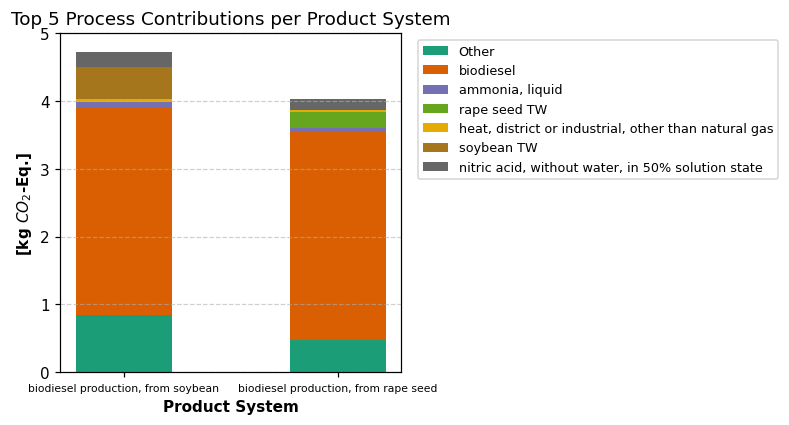

In [6]:
# Prepare data
all_labels = set()
top_contribs_per_system = []

for name, contribs in zip(target_systems, list_contribs):
    sorted_contribs = sorted(contribs, key=lambda x: x.amount, reverse=True)
    top_contribs = sorted_contribs[:5]
    other_amount = sum(c.amount for c in sorted_contribs[5:])
    
    print(f"\nContributions for '{name}':")
    for contrib in top_contribs:
        print(f"  Process: {contrib.tech_flow.flow.name}, Amount: {contrib.amount:.3f}")
    print(f"  Process: Other contributions, Amount: {other_amount:.3f}")


    label_amounts = {c.tech_flow.flow.name: c.amount for c in top_contribs}
    label_amounts["Other"] = other_amount
    
    all_labels.update(label_amounts.keys())
    top_contribs_per_system.append(label_amounts)

# Ensure consistent label order
all_labels = list(all_labels)

# Organize data into a matrix: rows = labels, columns = systems
data_matrix = []
for label in all_labels:
    row = [system_contribs.get(label, 0) for system_contribs in top_contribs_per_system]
    data_matrix.append(row)


# Plot
x = np.arange(len(target_systems))
fig, ax = plt.subplots(dpi = 110, figsize=(4, 4))
bottom = np.zeros(len(target_systems))

colors = plt.cm.Dark2(np.linspace(0, 1, len(all_labels)))

for i, (label, row) in enumerate(zip(all_labels, data_matrix)):
    ax.bar(x, row, bottom=bottom, label=label, color=colors[i], width=0.45)
    bottom += np.array(row)

# Labels and legend
ax.set_xticks(x)
ax.set_xticklabels(target_systems, fontsize=7)
ax.set_ylabel('[kg $CO_2$-Eq.]', fontweight='bold')
ax.set_xlabel('Product System', fontweight='bold')
ax.set_title('Top 5 Process Contributions per Product System')
ax.legend(loc='upper left', bbox_to_anchor=(1.03, 1), fontsize='small')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)



plt.ylim(0, 5)
plt.show()


The values represent the direct contribution of each process to the total environmental impact (in CO₂-equivalents) of biodiesel production. In both systems, the biodiesel production stage is the most significant contributor, primarily due to the high energy consumption in oil extraction and transesterification (Su & Lee, 2009).

## Monte Carlo simulations


Starting Monte Carlo for: biodiesel production, from soybean


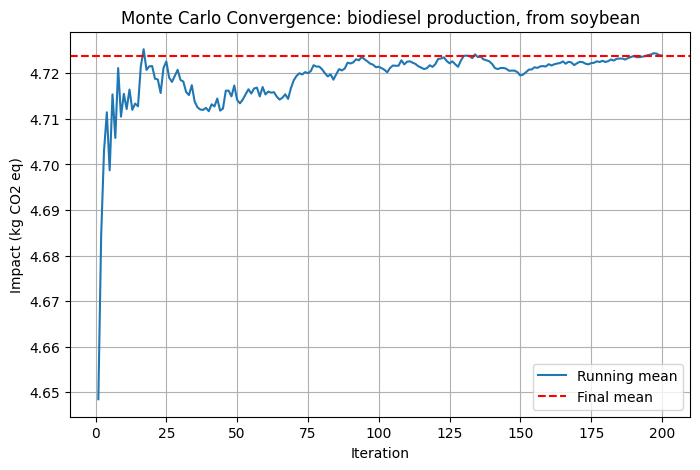


Starting Monte Carlo for: biodiesel production, from rape seed


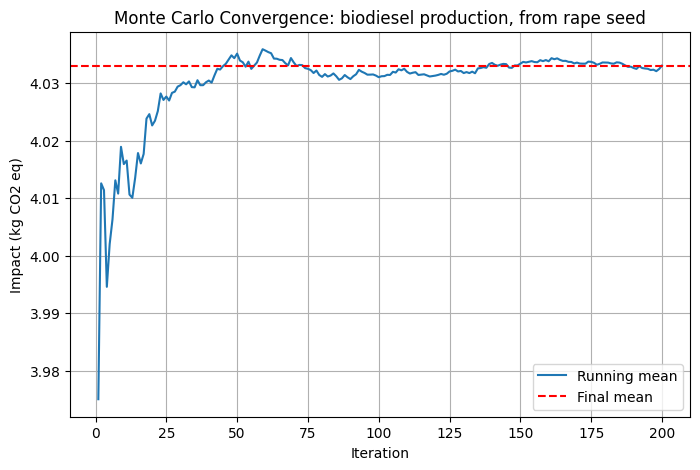


Summary of Monte Carlo Results:
                                      count      mean       std       min  \
product_system                                                              
biodiesel production, from rape seed  200.0  4.033079  0.038627  3.944172   
biodiesel production, from soybean    200.0  4.723903  0.064005  4.559981   

                                           25%       50%       75%      max  
product_system                                                               
biodiesel production, from rape seed  4.004594  4.030827  4.057721  4.14965  
biodiesel production, from soybean    4.676554  4.722606  4.768791  4.89896  


In [9]:

LCIA_method = 'IPCC 2013 GWP 100a'
num_iterations = 200
all_results=[]

for name in target_systems: # looping through product systems
    print(f"\nStarting Monte Carlo for: {name}")
    product_system = client.find(o.ProductSystem, name)
    impact_method = client.find(o.ImpactMethod, LCIA_method)

    result = client.simulate(
        o.CalculationSetup(
            target=product_system.to_ref(),
            impact_method=impact_method.to_ref(),
            amount=FU,
        )
    )
    result.wait_until_ready()

    indicator = rand.choice(result.get_impact_categories())
    val = lambda: result.get_total_impact_value_of(indicator).amount
   
    xs = [val()]
    for i in range(1, num_iterations):
        result.simulate_next()
        result.wait_until_ready()
        v = val()
        xs.append(v)

    # Store results
    for v in xs:
        all_results.append({
            "product_system": name,
            "impact": v
        })

    running_mean = np.cumsum(xs) / np.arange(1, len(xs) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_iterations + 1), running_mean, label="Running mean")
    plt.axhline(np.mean(xs), color='r', linestyle='--', label="Final mean")
    plt.xlabel("Iteration")
    plt.ylabel(f"Impact ({indicator.ref_unit})")
    plt.title(f"Monte Carlo Convergence: {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    result.dispose()

# Create summary
df = pd.DataFrame(all_results)
summary = df.groupby("product_system")["impact"].describe()
print("\nSummary of Monte Carlo Results:")
print(summary)

## Plot the Monte Carlo results

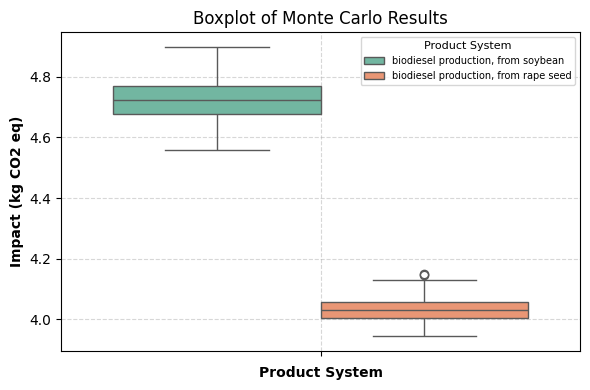

In [10]:
# Create the boxplot
plt.figure(figsize=(6, 4))
# sns.boxplot(data=df, x="product_system", y="impact", palette="Set2")
sns.boxplot(data=df, x=[""] * len(df), y="impact", hue="product_system", palette="Set2")
# sns.pointplot(data=df, x=[""] * len(df), y="impact", hue="product_system",
#               estimator="mean", dodge=0.4, join=False, markers="D", color="black")

# Add labels and title
plt.title("Boxplot of Monte Carlo Results")
plt.xlabel("Product System", fontweight='bold')
plt.ylabel(f"Impact ({indicator.ref_unit})", fontweight='bold')  # dynamic unit label
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
legend = plt.legend(
    title="Product System",
    title_fontsize='8',     # Font size of the legend title
    fontsize='7',           # Font size of the legend labels
    loc='upper right'       # You can change to: 'best', 'lower center', etc.
)
plt.show()

The graph shows the distribution of total CO₂-equivalent emissions from 200 Monte Carlo simulations for each biodiesel product system. Both systems have a narrow interquartile range, indicating moderate uncertainty around the median. Soybean-based biodiesel shows generally higher impact values and a slightly wider uncertainty spread compared to rapeseed-based biodiesel.